<a href="https://colab.research.google.com/github/paulahruizpro-ux/telecom-x-ii/blob/main/Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importar e extrair dados

In [1]:
!pip install pandas scikit-learn imblearn

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
dados = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Telecom 2/dados_tratados_telecom2.csv')

In [5]:
pd.set_option('display.max_columns', None)
dados.head()

,customer_id,churn,customer_gender,customer_senior_citizen,customer_partner,customer_dependents,customer_tenure,phone_phone_service,phone_multiple_lines,internet_internet_service,internet_online_security,internet_online_backup,internet_device_protection,internet_tech_support,internet_streaming_tv,internet_streaming_movies,account_contract,account_paperless_billing,account_payment_method,account_charges_monthly,account_charges_total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [6]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 7267 non-null   object 
 1   churn                       7043 non-null   object 
 2   customer_gender             7267 non-null   object 
 3   customer_senior_citizen     7267 non-null   int64  
 4   customer_partner            7267 non-null   object 
 5   customer_dependents         7267 non-null   object 
 6   customer_tenure             7267 non-null   int64  
 7   phone_phone_service         7267 non-null   object 
 8   phone_multiple_lines        7267 non-null   object 
 9   internet_internet_service   7267 non-null   object 
 10  internet_online_security    7267 non-null   object 
 11  internet_online_backup      7267 non-null   object 
 12  internet_device_protection  7267 non-null   object 
 13  internet_tech_support       7267 

In [7]:
#Quais colunas têm NaN
nan_cols = dados.columns[dados.isna().any()].to_list()
print("Colunas com NaN:", nan_cols)

Colunas com NaN: ['churn', 'account_charges_total']


In [8]:
#Remoção de Nan do Churn
dados = dados[dados['churn'].notna()].copy()

print(f'Linhas após limpeza: {len(dados)}')
print(f'Nan em churn: {dados['churn'].isna().sum()}')

Linhas após limpeza: 7043
Nan em churn: 0


In [9]:
# Imputação de NaN do account_charges_total
from sklearn.impute import SimpleImputer

#criar imputer com estratégia 'median'

imputer = SimpleImputer(strategy='median')

#seleciona coluna com Nan e com ravel substitui os valores originais
#pelos valores limpos

dados['account_charges_total'] = imputer.fit_transform(
    dados[['account_charges_total']]
).ravel()
print("NaNs após imputação:", dados['account_charges_total'].isna().sum())


NaNs após imputação: 0


In [10]:
dados.columns

Index(['customer_id', 'churn', 'customer_gender', 'customer_senior_citizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phone_service', 'phone_multiple_lines',
       'internet_internet_service', 'internet_online_security',
       'internet_online_backup', 'internet_device_protection',
       'internet_tech_support', 'internet_streaming_tv',
       'internet_streaming_movies', 'account_contract',
       'account_paperless_billing', 'account_payment_method',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')

In [11]:
dados.shape

(7043, 21)

In [12]:
#Remoção de colunas irrelevantes
dados = dados.drop(columns = 'customer_id')

In [13]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   churn                       7043 non-null   object 
 1   customer_gender             7043 non-null   object 
 2   customer_senior_citizen     7043 non-null   int64  
 3   customer_partner            7043 non-null   object 
 4   customer_dependents         7043 non-null   object 
 5   customer_tenure             7043 non-null   int64  
 6   phone_phone_service         7043 non-null   object 
 7   phone_multiple_lines        7043 non-null   object 
 8   internet_internet_service   7043 non-null   object 
 9   internet_online_security    7043 non-null   object 
 10  internet_online_backup      7043 non-null   object 
 11  internet_device_protection  7043 non-null   object 
 12  internet_tech_support       7043 non-null   object 
 13  internet_streaming_tv       7043 non-n

In [14]:
dados.columns

Index(['churn', 'customer_gender', 'customer_senior_citizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phone_service', 'phone_multiple_lines',
       'internet_internet_service', 'internet_online_security',
       'internet_online_backup', 'internet_device_protection',
       'internet_tech_support', 'internet_streaming_tv',
       'internet_streaming_movies', 'account_contract',
       'account_paperless_billing', 'account_payment_method',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')

In [15]:
dados.nunique()

,0
churn,2
customer_gender,2
customer_senior_citizen,2
customer_partner,2
customer_dependents,2
customer_tenure,73
phone_phone_service,2
phone_multiple_lines,3
internet_internet_service,3
internet_online_security,3


In [16]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [17]:
colunas = dados.columns

In [18]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['churn','customer_gender','customer_partner','customer_dependents',
     'phone_phone_service', 'phone_multiple_lines', 'internet_internet_service',
     'internet_online_security', 'internet_online_backup', 'internet_device_protection',
     'internet_tech_support', 'internet_streaming_tv',
     'internet_streaming_movies', 'account_contract',
     'account_paperless_billing', 'account_payment_method']
),
    remainder = 'passthrough',
    sparse_threshold = 0)

In [19]:
dados_encoded = one_hot.fit_transform(dados)

In [20]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__churn_Yes', 'onehotencoder__customer_gender_Male',
       'onehotencoder__customer_partner_Yes',
       'onehotencoder__customer_dependents_Yes',
       'onehotencoder__phone_phone_service_Yes',
       'onehotencoder__phone_multiple_lines_No',
       'onehotencoder__phone_multiple_lines_No phone service',
       'onehotencoder__phone_multiple_lines_Yes',
       'onehotencoder__internet_internet_service_DSL',
       'onehotencoder__internet_internet_service_Fiber optic',
       'onehotencoder__internet_internet_service_No',
       'onehotencoder__internet_online_security_No',
       'onehotencoder__internet_online_security_No internet service',
       'onehotencoder__internet_online_security_Yes',
       'onehotencoder__internet_online_backup_No',
       'onehotencoder__internet_online_backup_No internet service',
       'onehotencoder__internet_online_backup_Yes',
       'onehotencoder__internet_device_protection_No',
       'onehotencoder__internet_device_protec

In [21]:
dados_encoded= pd.DataFrame(dados_encoded,columns= one_hot.get_feature_names_out(colunas))
dados_encoded

,onehotencoder__churn_Yes,onehotencoder__customer_gender_Male,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phone_service_Yes,onehotencoder__phone_multiple_lines_No,onehotencoder__phone_multiple_lines_No phone service,onehotencoder__phone_multiple_lines_Yes,onehotencoder__internet_internet_service_DSL,onehotencoder__internet_internet_service_Fiber optic,onehotencoder__internet_internet_service_No,onehotencoder__internet_online_security_No,onehotencoder__internet_online_security_No internet service,onehotencoder__internet_online_security_Yes,onehotencoder__internet_online_backup_No,onehotencoder__internet_online_backup_No internet service,onehotencoder__internet_online_backup_Yes,onehotencoder__internet_device_protection_No,onehotencoder__internet_device_protection_No internet service,onehotencoder__internet_device_protection_Yes,onehotencoder__internet_tech_support_No,onehotencoder__internet_tech_support_No internet service,onehotencoder__internet_tech_support_Yes,onehotencoder__internet_streaming_tv_No,onehotencoder__internet_streaming_tv_No internet service,onehotencoder__internet_streaming_tv_Yes,onehotencoder__internet_streaming_movies_No,onehotencoder__internet_streaming_movies_No internet service,onehotencoder__internet_streaming_movies_Yes,onehotencoder__account_contract_Month-to-month,onehotencoder__account_contract_One year,onehotencoder__account_contract_Two year,onehotencoder__account_paperless_billing_Yes,onehotencoder__account_payment_method_Bank transfer (automatic),onehotencoder__account_payment_method_Credit card (automatic),onehotencoder__account_payment_method_Electronic check,onehotencoder__account_payment_method_Mailed check,remainder__customer_senior_citizen,remainder__customer_tenure,remainder__account_charges_monthly,remainder__account_charges_total
0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9.0,65.60,593.30
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,59.90,542.40
2,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4.0,73.90,280.85
3,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,13.0,98.00,1237.85
4,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,3.0,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0,55.15,742.90
7039,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,22.0,85.10,1873.70
7040,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,50.30,92.75
7041,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,67.0,67.85,4627.65


**Verificação da Proporção de Cancelamento (Churn)**

In [22]:
dados_encoded['onehotencoder__churn_Yes'].value_counts()

,count
onehotencoder__churn_Yes,
0.0,5174
1.0,1869


In [23]:
print('Proporção de cancelamentos:')
print()
contagem = dados_encoded['onehotencoder__churn_Yes'].value_counts()
porcentagem = dados_encoded['onehotencoder__churn_Yes'].value_counts(normalize=True) * 100

#juntar duas series com concat()
#axis=1 coloca em colunas
#keys nomeia as colunas

tabela = pd.concat([contagem, porcentagem.round(1)], axis=1,
                   keys=['Contagem', 'Porcentagem(%)'])

print(tabela.reset_index(drop=True))

Proporção de cancelamentos:

   Contagem  Porcentagem(%)
0      5174            73.5
1      1869            26.5


Balancear


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

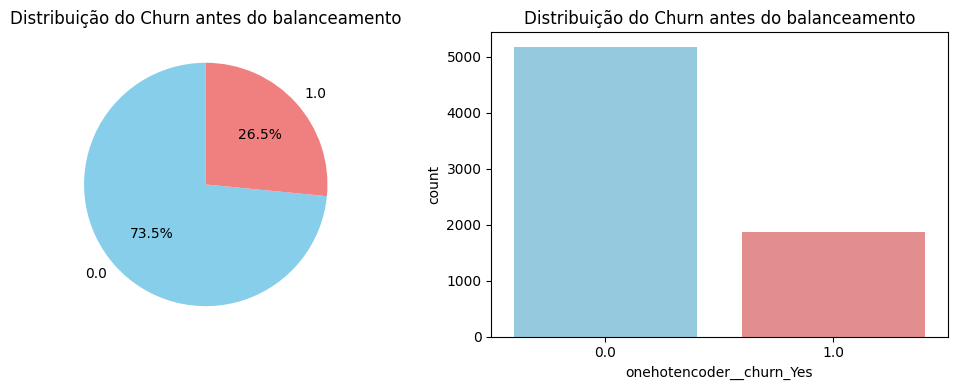

In [25]:
#Plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

#Plot pizza
pie_colors=['skyblue','lightcoral']
axes[0].pie(dados_encoded['onehotencoder__churn_Yes'].value_counts(), labels=dados_encoded['onehotencoder__churn_Yes'].value_counts().index, autopct='%1.1f%%',
            startangle=90, colors=pie_colors)
axes[0].set_title('Distribuição do Churn antes do balanceamento')

#Plot de contagem

countplot_colors = sns.color_palette(pie_colors)
sns.countplot(x='onehotencoder__churn_Yes', hue = 'onehotencoder__churn_Yes',
              data = dados_encoded, palette = countplot_colors, ax=axes[1],
              legend=False)
axes[1].set_title('Distribuição do Churn antes do balanceamento')

plt.tight_layout()
plt.show()


Separar os dados entre explicativas(X) e alvo(y)

In [26]:
X = dados_encoded.drop('onehotencoder__churn_Yes', axis = 1)
y = dados_encoded[['onehotencoder__churn_Yes']]

X.shape, y.shape

((7043, 40), (7043, 1))

In [27]:
#Dividir dados entre treino e teste
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(X,y, test_size=0.2, random_state = 42)

X_treino.shape, X_teste.shape, y_treino.shape, y_teste.shape

((5634, 40), (1409, 40), (5634, 1), (1409, 1))

In [33]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

def validacao_cruzada(modelo, X, y, oversampling=False):
  #divide em 10 partes iguais
  kfold = KFold(n_splits=10)
  acuracias_split = []

#kfold gera pares de índices de treino e de validação

#iterando sobre os splits
  for idx, (idx_treino, idx_validacao) in enumerate(kfold.split(X)):
    X_split_treino = X.iloc[idx_treino, :]
    y_split_treino = y.iloc[idx_treino, :]

#oversampling só no split de treino
    if oversampling:
      sm = SMOTE(random_state=42)
      X_split_treino, y_split_treino = sm.fit_resample(X_split_treino, y_split_treino)

    modelo.fit(X_split_treino, y_split_treino.values.flatten())

    X_split_validacao = X.iloc[idx_validacao, :]
    y_split_validacao = y.iloc[idx_validacao, :]

    predicoes = modelo.predict(X_split_validacao)

    acuracia_split = accuracy_score(y_split_validacao, predicoes)

    acuracias_split.append(acuracia_split)

    print(f'A acurácia do split {idx}:{acuracia_split}')

  return acuracias_split




In [34]:
from sklearn.ensemble import HistGradientBoostingClassifier
from statistics import mean

#criando o modelo
modelo_hgb = HistGradientBoostingClassifier()

In [35]:
media_acuracia_sem_smote = mean(validacao_cruzada(modelo_hgb, X_treino, y_treino, oversampling = False))

A acurácia do split 0:0.8014184397163121
A acurácia do split 1:0.7925531914893617
A acurácia do split 2:0.7960992907801419
A acurácia do split 3:0.8014184397163121
A acurácia do split 4:0.7779751332149201
A acurácia do split 5:0.7744227353463587
A acurácia do split 6:0.7957371225577264
A acurácia do split 7:0.7975133214920072
A acurácia do split 8:0.7886323268206039
A acurácia do split 9:0.7904085257548845


In [38]:
media_acuracia_sem_smote

0.7916178526888629

In [36]:
media_acuracia_com_smote = mean(validacao_cruzada(modelo_hgb, X_treino, y_treino, oversampling = True))

A acurácia do split 0:0.8120567375886525
A acurácia do split 1:0.7695035460992907
A acurácia do split 2:0.7783687943262412
A acurácia do split 3:0.7943262411347518
A acurácia do split 4:0.7904085257548845
A acurácia do split 5:0.7957371225577264
A acurácia do split 6:0.7921847246891652
A acurácia do split 7:0.7921847246891652
A acurácia do split 8:0.7921847246891652
A acurácia do split 9:0.783303730017762


In [39]:
media_acuracia_com_smote

0.7900258871546805

In [40]:
f'Sem smote: {media_acuracia_sem_smote:.02f}, Com smote: {media_acuracia_com_smote:.02f}'

'Sem smote: 0.79, Com smote: 0.79'

In [41]:
sm = SMOTE(random_state=42)
X_treino_balanceado, y_treino_balanceado = sm.fit_resample(X_treino, y_treino)